1. MNIST ma’lumotlarini tayyorlash





torchvision kutubxonasi yordamida MNIST ma’lumotlar to‘plamini yuklab oling.



Ma’lumotlarni tensorlarga o‘tkazing.



DataLoader yordamida o‘rgatish uchun tayyorlang.

2. Model arxitekturasini yaratish

Kiruvchi qatlamda 784 ta neyron (28x28 piksel), yashirin qatlamda 128 ta neyron (ReLU aktivatsiya funksiyasi bilan) va chiquvchi qatlamda 10 ta neyron (0 dan 9 gacha bo‘lgan raqamlar uchun) bo‘lgan nn.Sequential modelini yarating.

3. Yo‘qotish funksiyasi va optimayzerni sozlash

Ko‘p klassli tasniflash uchun nn.CrossEntropyLoss yo‘qotish funksiyasini va optim.SGD optimayzerini lr=0.01 (learning rate) bilan sozlang.

4. Modelni shug‘ullantirish va natijani tahlil qilish





5 ta epocha davomida modelni shug‘ullantiradigan tsikl yarating.



Har bir epocha oxirida o‘rtacha yo‘qotish qiymatini ekranga chiqaring.



Shug‘ullantirish jarayonidan so‘ng yo‘qotish grafigini chizing.

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
#rasm yaratadi va uni tensorga (255) ga o'tqazadi undan keyin 0.0-1.0 oralig'iga olib keladi
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
#MNIST dataset chaqiryapmiz
train_dataset = datasets.MNIST(
    root='./data',             #malumot papkaga saqlanadi
    train=True,                #modelni o‘rgatish uchun (60,000 rasm)
    download=True,             #yuklab oladi
    transform=transform        #rasm tensor bo‘ladi
)

test_dataset = datasets.MNIST(
    root='./data',             #malumot papkaga saqlanadi
    train=False,               #modelni test uchun (10,000 rasm)
    download=True,             #yuklab oladi
    transform=transform        #rasm tensor bo‘ladi
)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
  #batch_size=64 har safar 64 ta rasm modelga beriladi
  #shuffle=True dataset aralashtiriladi
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
  #batch_size=64 har safar 64 ta rasm modelga beriladi
  #shuffle=False dataset aralashtirilmaydi


In [ ]:
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),          # 28x28 ni 784 ga aylantiradi
    nn.Linear(784, 128),   # kirish -> yashirin qatlam
    nn.ReLU(),             # aktivatsiya funksiyasi
    nn.Linear(128, 10)     # yashirin -> chiqish
)

In [ ]:
criterion = nn.CrossEntropyLoss()
#model xatosini hisoblaydi
#classification uchun

In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr=0.01)
#vaznlarni yangilaydi
#lr qanchalik tex organishi

In [ ]:
#epoch
losses = []                               #yo'qotisglar uchun fayl
num_epochs = 5                            #necha marotaba qaytarilishi

for epoch in range(num_epochs):
    running_loss = 0.0
                                          #har epoch uchun loss yig‘iladi

    for images, labels in train_loader:
        # Forward
        outputs = model(images)           #model rasmni ko‘rib, taxmin qiladi
        loss = criterion(outputs, labels) #model xatosi hisoblanadi

        # Backward
        optimizer.zero_grad()             #oldingi gradientlar o‘chiriladi
        loss.backward()                   #xatolik orqaga tarqaladi
        optimizer.step()                  #model o‘zini to‘g‘rilaydi

        running_loss += loss.item()       #o‘rtacha loss

    avg_loss = running_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], O'rtacha Loss: {avg_loss:.4f}")

Epoch [1/5], O'rtacha Loss: 1.2539
Epoch [2/5], O'rtacha Loss: 0.4973
Epoch [3/5], O'rtacha Loss: 0.3937
Epoch [4/5], O'rtacha Loss: 0.3532
Epoch [5/5], O'rtacha Loss: 0.3291


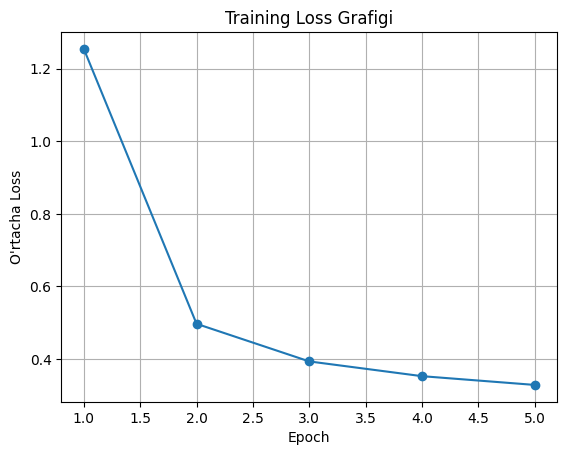

In [ ]:
#yo'qotish grafigi
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.title("Training Loss Grafigi")
plt.xlabel("Epoch")
plt.ylabel("O'rtacha Loss")
plt.grid(True)
plt.show()

MNIST → Tensor → DataLoader → Model → Loss → Backprop → Update → Repeat

Rasmni oladi

Modelga beradi

Model taxmin qiladi

Xato hisoblanadi

Model o‘zini tuzatadi

Yana takrorlanadi

Bu kodda:

MNIST dataset yuklab olinadi va tensor ko‘rinishga o‘tkaziladi
DataLoader orqali ma’lumotlar batchlarga ajratiladi
Oddiy neyron tarmoq (784 → 128 → 10) yaratiladi
CrossEntropyLoss va SGD yordamida model o‘rgatiladi
5 epocha davomida training qilinadi va loss hisoblanadi
Oxirida loss grafigi chizilib, model o‘rganishi tahlil qilinadi